In [20]:
import pickle
import pandas as pd
import numpy as np
import plotly.express as px
import os
import matplotlib.pyplot as plt
import sys
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sns
import umap.umap_ as umap

In [21]:
sys.path.append('/home/dg204/projects/rsignatures/src/extraction')
from sorted_array import SORTED_CAT_ARRAY

In [22]:
import plotly.io as pio
pio.renderers.default = "notebook"   # or "notebook_connected", "iframe", "colab"

In [23]:
import matplotlib as mpl
# 1. Make sure text stays as text in vector outputs (PDF, SVG, etc.)
mpl.rcParams['pdf.fonttype'] = 42   # Ensures text is stored as editable text
mpl.rcParams['ps.fonttype'] = 42    # (Optional) for EPS compatibility

In [24]:
# ----------------- Inputs -----------------
#exp_name='default'
#exp_name='channels32'
exp_name='non_clustered'
#exp_name='non_clustered_normalized'
#exp_name='non_clustered_corr_normalized'

dataset = '_pancan_sel'

#labels_fn='/home/dg204/projects/polysignatures/data/processed/breast.labels.251105.csv'
labels_fn='/home/dg204/projects/rsignatures/data/processed/pcawg_labels.csv'
#labels_fn=None

In [25]:
solutionDict={}
#solutionDict['non_clustered'] = 12
#solutionDict['non_clustered_corr_normalized'] = 15
#solutionDict['non_clustered_corr_normalized'] = 15 # temp

if exp_name in solutionDict.keys():
    force_solution=solutionDict[exp_name]
else:
    force_solution=None


In [26]:
if exp_name=='default':
    pkl_file = '/n/data1/hms/dbmi/park/michail_a/SV_Signatures_Project/SignatureExtractionResults/SV_SigExtraction_nmf_RFD.pkl'
    X_file = '/n/data1/hms/dbmi/park/michail_a/SV_Signatures_Project/data/X_SV_RFD.csv'
else:
    pkl_file = '/home/dg204/park_dglodzik/svig/extractionLogs/SV_SigExtraction_nmf_RFD_'+exp_name+dataset+'.pkl'
    X_file = '/home/dg204/park_dglodzik/svig/extractionLogs/X_'+exp_name+dataset+'.csv'





output_dir = '/home/dg204/park_dglodzik/SVsigs/RFD/'+exp_name+dataset+'/'
os.makedirs(output_dir, exist_ok=True)

output_dir_corr = '/home/dg204/park_dglodzik/SVsigs/RFD/'+exp_name+dataset+'_corr/'
os.makedirs(output_dir_corr, exist_ok=True)

# ----------------- Load model -----------------
with open(pkl_file, 'rb') as f:
    model_loaded = pickle.load(f)
    
if force_solution is None:
    deNovoSigs = pd.DataFrame(model_loaded.W)
    H_sel = pd.DataFrame(model_loaded.H.T)
    sil_scores = model_loaded.sil_score
else:
    deNovoSigs = pd.DataFrame(model_loaded.W_all[force_solution])
    sil_scores = model_loaded.sil_score_all[force_solution]
    H_sel = pd.DataFrame(model_loaded.H_all[force_solution].T)

deNovoSigs.columns = [f"Signature {i+1}" for i in range(deNovoSigs.shape[1])]
H_sel.columns = [f"Signature {i+1}" for i in range(deNovoSigs.shape[1])]
H_sel.index = model_loaded.samples
sil_scores_dict = dict(zip([f"Signature {i+1}" for i in range(deNovoSigs.shape[1])], sil_scores))

X = pd.read_csv(X_file, index_col=0)
deNovoSigs.index = model_loaded.features
deNovoSigs_expanded = deNovoSigs.reindex(X.index)
deNovoSigs = deNovoSigs_expanded


if (exp_name=='channels32'):
    deNovoSigs.index = deNovoSigs.index + '_L_L'
    X.index = X.index + '_L_L'

In [68]:
deNovoSigs.to_csv(output_dir_corr + "deNovoSigs.csv")

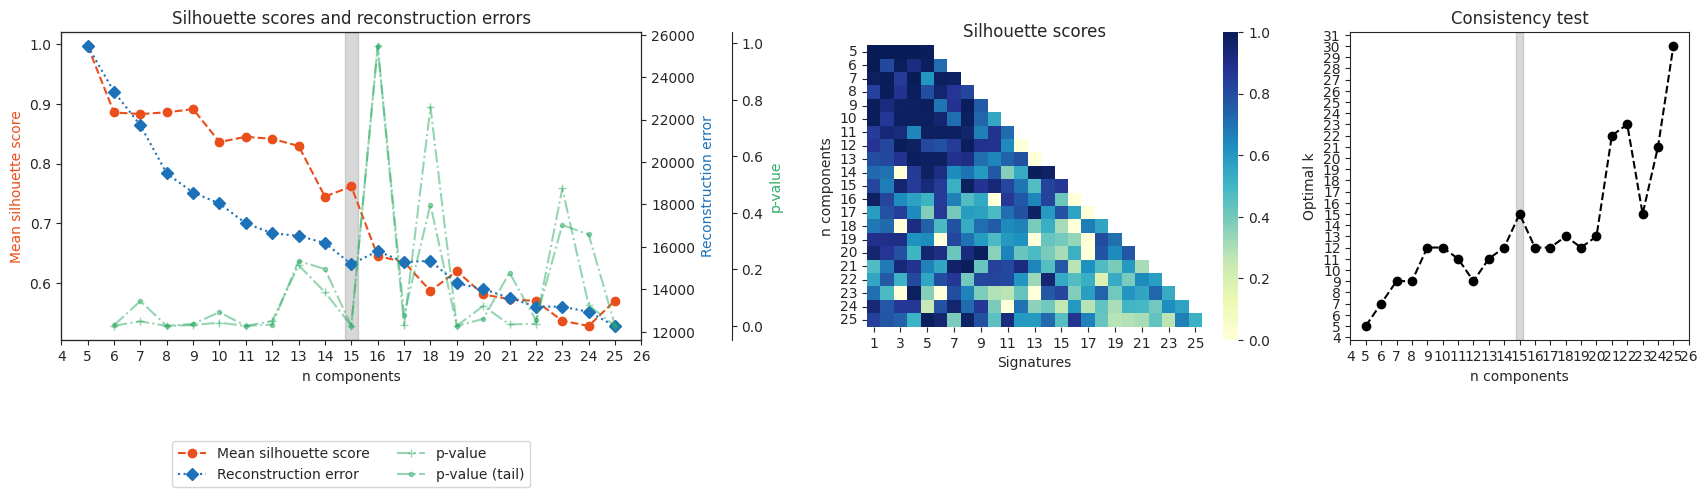

In [27]:
model_loaded.plot_selection()

In [28]:
pkl_file

'/home/dg204/park_dglodzik/svig/extractionLogs/SV_SigExtraction_nmf_RFD_non_clustered_pancan_sel.pkl'

In [29]:
X_file

'/home/dg204/park_dglodzik/svig/extractionLogs/X_non_clustered_pancan_sel.csv'

In [30]:
sorted_array = SORTED_CAT_ARRAY

color_map = {
    # Deletions - shades of red
    'Clustered Deletion (L_L)': '#c61033', # Light red
    'Clustered Deletion (L_R)': '#c61033',  # Medium red
    'Clustered Deletion (R_L)': '#c61033',  # Dark red
    'Clustered Deletion (R_R)': '#c61033', # Bright red
    'Non-clustered Deletion (L_L)': '#c61033',  # Light red
    'Non-clustered Deletion (L_R)': '#c61033',  # Medium red
    'Non-clustered Deletion (R_L)': '#c61033',  # Dark red
    'Non-clustered Deletion (R_R)': '#c61033',  # Bright red
    
    # Inversions - shades of blue
    'Clustered Inversion (L_L)': '#3b74ac',  # Light blue
    'Clustered Inversion (L_R)': '#3b74ac',  # Medium blue
    'Clustered Inversion (R_L)': '#3b74ac',  # Dark blue
    'Clustered Inversion (R_R)': '#3b74ac',  # Bright blue
    'Non-clustered Inversion (L_L)': '#3b74ac',  # Light blue
    'Non-clustered Inversion (L_R)': '#3b74ac',  # Medium blue
    'Non-clustered Inversion (R_L)': '#3b74ac',  # Dark blue
    'Non-clustered Inversion (R_R)': '#3b74ac',  # Bright blue
    
    # Tandem Duplications - shades of green
    'Clustered Tandem Duplication (L_L)': '#44a23c',  # Light green
    'Clustered Tandem Duplication (L_R)': '#44a23c',  # Medium green
    'Clustered Tandem Duplication (R_L)': '#44a23c',  # Dark green
    'Clustered Tandem Duplication (R_R)': '#44a23c',  # Bright green
    'Non-clustered Tandem Duplication (L_L)': '#44a23c',  # Light green
    'Non-clustered Tandem Duplication (L_R)': '#44a23c',  # Medium green
    'Non-clustered Tandem Duplication (R_L)': '#44a23c',  # Dark green
    'Non-clustered Tandem Duplication (R_R)': '#44a23c',  # Bright green
    
    # Translocations - shades of purple
    'Clustered Translocation (L_L)': '#833792', # Light purple
    'Clustered Translocation (L_R)': '#833792',  # Medium purple
    'Clustered Translocation (R_L)': '#833792',  # Dark purple
    'Clustered Translocation (R_R)': '#833792',  # Bright purple
    'Non-clustered Translocation (L_L)': '#833792',  # Light purple
    'Non-clustered Translocation (L_R)': '#833792',  # Medium purple
    'Non-clustered Translocation (R_L)': '#833792',  # Dark purple
    'Non-clustered Translocation (R_R)': '#833792',  # Bright purple
}

colDict = {}
colDict['del'] = '#c61033'
colDict['tds'] = '#44a23c'
colDict['inv'] = '#3b74ac'
colDict['trans'] = '#833792'

In [31]:
# ----------------- Plotting function -----------------
def plot_mut_spectrum(mutation_vector, sorted_array, color_map, title, output_dir, show=True, showPdf=False):
    def categorize_mutation(mutation):
        cluster = "Clustered" if mutation.startswith("clustered_") else "Non-clustered"
        if "_del_" in mutation:
            mtype = "Deletion"
        elif "_inv_" in mutation:
            mtype = "Inversion"
        elif "_tds_" in mutation:
            mtype = "Tandem Duplication"
        elif "_trans_" in mutation:
            mtype = "Translocation"
        else:
            mtype = "Other"
        subcat = "_".join(mutation.split("_")[-2:])
        return f"{cluster} {mtype} ({subcat})"

    df = mutation_vector.copy()
    df["Group"] = df["MutationType"].apply(categorize_mutation)
    df["Color"] = df["Group"].map(color_map)
    df["MutationType"] = pd.Categorical(df["MutationType"], categories=sorted_array, ordered=True)
    df.sort_values("MutationType", inplace=True)
    df.reset_index(drop=True, inplace=True)

    fig = px.bar(
        df, x="MutationType", y="Total Count", color="Group", title=title,
        labels={"Total Count": "Mutation Count", "MutationType": "Mutation Type"},
        color_discrete_map=color_map, text_auto=False,
        category_orders={"MutationType": sorted_array}
    )
    fig.update_traces(marker_line_width=0)
    fig.update_layout(title_x=0.5)

    y_max = df["Total Count"].max()
    for i in range(0, 129, 4):
        fig.add_vline(x=i - 0.5, line_dash="dot", line_color="grey", opacity=0.6, line_width=0.3)

    extra_bars = [
        (0, 20, "Deletions", '#c61033'),
        (20, 40, "Duplications", '#44a23c'),
        (40, 60, "Inversions", '#3b74ac'),
        (60, 64, "Trans", '#833792'),
        (64, 84, "Deletions", '#c61033'),
        (84, 104, "Duplications", '#44a23c'),
        (104, 124, "Inversions", '#3b74ac'),
        (124, 128, "Trans", '#833792')
    ]

    for start, end, label, color in extra_bars:
        fig.add_shape(type="rect", x0=start - 0.5, x1=end - 0.5,
                      y0=y_max * 1.10, y1=y_max * 1.15,
                      line=dict(width=0), fillcolor=color, opacity=1)
        fig.add_annotation(x=(start + end) / 2 - 0.5, y=(y_max * 1.10 + y_max * 1.15) / 2,
                           text=label, showarrow=False, font=dict(size=10, color="white"))

    def add_horizontal_bar(start, end, y, label, color, opacity=1):
        fig.add_shape(type="rect", x0=start - 0.5, x1=end - 0.5,
                      y0=y, y1=y * (1.20 / 1.15),
                      line=dict(width=0), fillcolor=color, opacity=opacity)
        fig.add_annotation(x=(start + end) / 2 - 0.5, y=(y + y * (1.15 / 1.10)) / 2,
                           text=label, showarrow=False, font=dict(size=10, color="white"))

    horizontal_bars = [
        (0, 64, y_max * 1.15, "Clustered", 'black'),
        (64, 128, y_max * 1.15, "Non-Clustered", 'lightgrey')
    ]
    for bar in horizontal_bars:
        add_horizontal_bar(*bar)

    fig.update_layout(
        yaxis_title="Fraction of Total Mutations",
        xaxis_title="Mutation Types",
        xaxis_tickangle=-90,
        yaxis=dict(range=[0, y_max * 1.20]),
        showlegend=False
    )

    section_labels = ['1-10Kb', '10-100Kb', '100Kb-1Mb', '1Mb-10Mb', '>10Mb']
    orientations = ['L_L', 'L_R', 'R_L', 'R_R']
    combined_sections = [f"{sec} {ori}" for sec in section_labels for ori in orientations]
    repeated_labels = combined_sections * 3 + orientations + combined_sections * 3 + orientations

    fig.update_layout(
        xaxis=dict(tickmode='array', tickvals=np.arange(128), ticktext=repeated_labels, tickangle=-90),
        height=400, width=1100
    )

    fig.update_layout(
        showlegend=False,
        paper_bgcolor='white',  # Set background color to white
        plot_bgcolor='white'    # Set plot area background color to white
    )

    fig.update_layout(
        font=dict(
            family="Arial",
            size=9,
            color="black"
        )
    )

    if show:
        if showPdf:
            fig.show()
            print('writing PDF')
            pdf_path = f"{output_dir}/{title}.pdf"
            print(pdf_path)
            fig.write_image(pdf_path, format='pdf', width=1100, height=400, scale=3)
        else: 
            fig.show()
            print(f"{output_dir}/{title}.jpg")
            fig.write_image(f"{output_dir}/{title}.jpg", format='jpg', scale=3)

In [51]:
def plot_mut_spectrum2(
    mutation_vector, sorted_array, color_map, title, output_dir,
    show=True, showPdf=False, only_nonclustered_td=False
):
    import pandas as pd
    import numpy as np
    import plotly.express as px
    import plotly.graph_objects as go

    # -----------------------------------------------------------
    # Helper: classify mutation
    # -----------------------------------------------------------
    def categorize_mutation(mutation):
        cluster = "Clustered" if mutation.startswith("clustered_") else "Non-clustered"
        if "_del_" in mutation:
            mtype = "Deletion"
        elif "_inv_" in mutation:
            mtype = "Inversion"
        elif "_tds_" in mutation:
            mtype = "Tandem Duplication"
        elif "_trans_" in mutation:
            mtype = "Translocation"
        else:
            mtype = "Other"
        subcat = "_".join(mutation.split("_")[-2:])
        return f"{cluster} {mtype} ({subcat})"

    df = mutation_vector.copy()

    # -----------------------------------------------------------
    # FILTER MODE: Only non-clustered tandem duplications
    # -----------------------------------------------------------
    if only_nonclustered_td:

        df = df[
            df["MutationType"].str.startswith("non-clustered_") &
            df["MutationType"].str.contains("_tds_") &
            ~df["MutationType"].str.contains('tds_>10Mb')
        ]
        df["Group"] = df["MutationType"].apply(categorize_mutation)

        # Update category list to match filtered data
        sorted_array = [c for c in sorted_array if c in df["MutationType"].unique()]

        # Extract prefix (SV size bin) and suffix (orientation)
        df["prefix"] = df["MutationType"].str.extract(r"tds_(.+?)_[LR]_[LR]")
        df["suffix"] = df["MutationType"].str.extract(r"(_[LR]_[LR])$")

        # Sort by prefix first, then suffix in L_L, L_R, R_L, R_R order
        suffix_order = ["L-L", "L-R", "R-L", "R-R"]
        df["suffix"] = pd.Categorical(
            df["suffix"].str[1:].str.replace("_", "-", regex=False),
            categories=suffix_order,
            ordered=True
        )
        
        df.sort_values(["prefix", "suffix"], inplace=True)

        # Reset index so that x positions are clean 0..N-1
        df.reset_index(drop=True, inplace=True)

        # -----------------------------------------------------------
        # TD-only plot
        # -----------------------------------------------------------
        fig = px.bar(
            df,
            x=df.index,  # x = numeric positions
            y="Total Count",
            color="Group",
            labels={"Total Count": "Mutation Count"},
            color_discrete_map=color_map
        )

        fig.update_traces(marker_line_width=0)
        fig.update_layout(title_x=0.5)

        y_max = df["Total Count"].max() if len(df) > 0 else 1

        # -----------------------------------------------------------
        # Vertical dashed lines between categories
        # -----------------------------------------------------------
        for i in range(0, len(df), 4):
            fig.add_vline(
                x=i - 0.5,
                line_dash="dot",
                line_color="grey",
                opacity=0.6,
                line_width=0.6
            )

        # -----------------------------------------------------------
        # Replace x-ticks with short suffix labels
        # -----------------------------------------------------------
        fig.update_xaxes(
            tickmode="array",
            tickvals=list(df.index),
            ticktext=df["suffix"].astype(str).tolist(),
            tickangle=-45
        )

        # -----------------------------------------------------------
        # Add prefix labels above groups of 4 bars
        # -----------------------------------------------------------
        for prefix in df["prefix"].unique():
            group_idx = df.index[df["prefix"] == prefix].tolist()
            if len(group_idx) == 0:
                continue
            start = min(group_idx)
            end = max(group_idx)
            mid = (start + end) / 2

            fig.add_annotation(
                x=mid,
                y=y_max * 1.05,
                text=prefix,
                showarrow=False,
                font=dict(size=11, color="black")
            )

        fig.update_layout(
            height=450,
            width=739,
            yaxis=dict(range=[0, y_max * 1.20]),
            xaxis_title="",
            yaxis_title="Mutation Count",
            plot_bgcolor="white",
            paper_bgcolor="white",
            showlegend=False,
            font=dict(family="Arial", size=10, color="black")
        )
        fig.update_layout(
            margin=dict(l=0, r=0, t=10, b=0),
        )

    # =======================================================================
    # FULL COMPLEX MODE (original 128-category mutation spectrum)
    # =======================================================================
    else:
        df["Group"] = df["MutationType"].apply(categorize_mutation)
        df["Color"] = df["Group"].map(color_map)
        df["MutationType"] = pd.Categorical(df["MutationType"],
                                            categories=sorted_array,
                                            ordered=True)
        df.sort_values("MutationType", inplace=True)
        df.reset_index(drop=True, inplace=True)

        fig = px.bar(
            df,
            x="MutationType",
            y="Total Count",
            color="Group",
            title=title,
            labels={"Total Count": "Mutation Count", "MutationType": "Mutation Type"},
            color_discrete_map=color_map,
            text_auto=False,
            category_orders={"MutationType": sorted_array}
        )

        fig.update_traces(marker_line_width=0)
        fig.update_layout(title_x=0.5)

        y_max = df["Total Count"].max()

        # Vertical dashed lines
        for i in range(0, 129, 4):
            fig.add_vline(x=i - 0.5, line_dash="dot",
                          line_color="grey", opacity=0.6, line_width=0.3)

        # Header rectangles + labels (unchanged from your original)
        extra_bars = [
            (0, 20, "Deletions", '#c61033'),
            (20, 40, "Duplications", '#44a23c'),
            (40, 60, "Inversions", '#3b74ac'),
            (60, 64, "Trans", '#833792'),
            (64, 84, "Deletions", '#c61033'),
            (84, 104, "Duplications", '#44a23c'),
            (104, 124, "Inversions", '#3b74ac'),
            (124, 128, "Trans", '#833792')
        ]

        for start, end, label, color in extra_bars:
            fig.add_shape(
                type="rect",
                x0=start - 0.5, x1=end - 0.5,
                y0=y_max * 1.10, y1=y_max * 1.15,
                line=dict(width=0),
                fillcolor=color, opacity=1
            )
            fig.add_annotation(
                x=(start + end) / 2 - 0.5,
                y=(y_max * 1.10 + y_max * 1.15) / 2,
                text=label,
                showarrow=False,
                font=dict(size=10, color="white")
            )

        # Clustered / Non-clustered grey/black bars
        def add_horizontal_bar(start, end, y, label, color, opacity=1):
            fig.add_shape(type="rect",
                          x0=start - 0.5, x1=end - 0.5,
                          y0=y, y1=y * (1.20 / 1.15),
                          line=dict(width=0), fillcolor=color, opacity=opacity)
            fig.add_annotation(
                x=(start + end) / 2 - 0.5,
                y=(y + y * (1.15 / 1.10)) / 2,
                text=label, showarrow=False,
                font=dict(size=10, color="white")
            )

        horizontal_bars = [
            (0, 64, y_max * 1.15, "Clustered", 'black'),
            (64, 128, y_max * 1.15, "Non-Clustered", 'lightgrey')
        ]
        for bar in horizontal_bars:
            add_horizontal_bar(*bar)

        # Custom tick labels for full spectrum
        section_labels = ['1-10Kb', '10-100Kb', '100Kb-1Mb', '1Mb-10Mb', '>10Mb']
        orientations = ['L_L', 'L_R', 'R_L', 'R_R']
        combined_sections = [f"{sec} {ori}" for sec in section_labels for ori in orientations]
        repeated_labels = combined_sections * 3 + orientations + combined_sections * 3 + orientations

        fig.update_layout(
            xaxis=dict(
                tickmode='array',
                tickvals=np.arange(128),
                ticktext=repeated_labels,
                tickangle=-90
            ),
            height=400,
            width=1100,
            yaxis=dict(range=[0, y_max * 1.20]),
            showlegend=False,
            plot_bgcolor='white',
            paper_bgcolor='white',
            font=dict(family="Arial", size=9, color="black")
        )

    # -----------------------------------------------------------
    # SAVE / SHOW
    # -----------------------------------------------------------
    if show:
        if showPdf:
            fig.show()
            pdf_path = f"{output_dir}/{title}.pdf"
            print("writing PDF:", pdf_path)
            if only_nonclustered_td:
                fig.write_image(pdf_path, format='pdf', width=655, height=400, scale=3)
            else:
                fig.write_image(pdf_path, format='pdf', width=1100, height=400, scale=3)
        else:
            fig.show()
            jpg_path = f"{output_dir}/{title}.jpg"
            print(jpg_path)
            fig.write_image(jpg_path, format='jpg', scale=3)


/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel//Signature 1 sil score: 0.82.jpg


writing PDF
/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 1 sil score: 0.82.pdf


writing PDF: /home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 1_only_dups.pdf


/tmp/ipykernel_2151685/1704116018.py:62: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



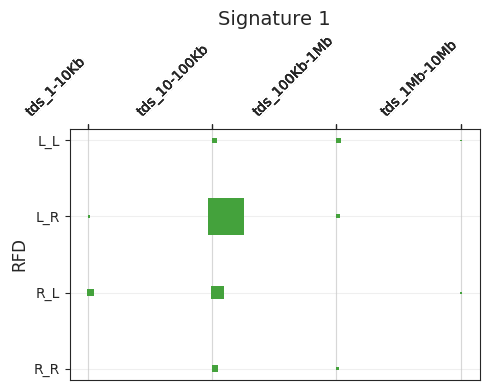

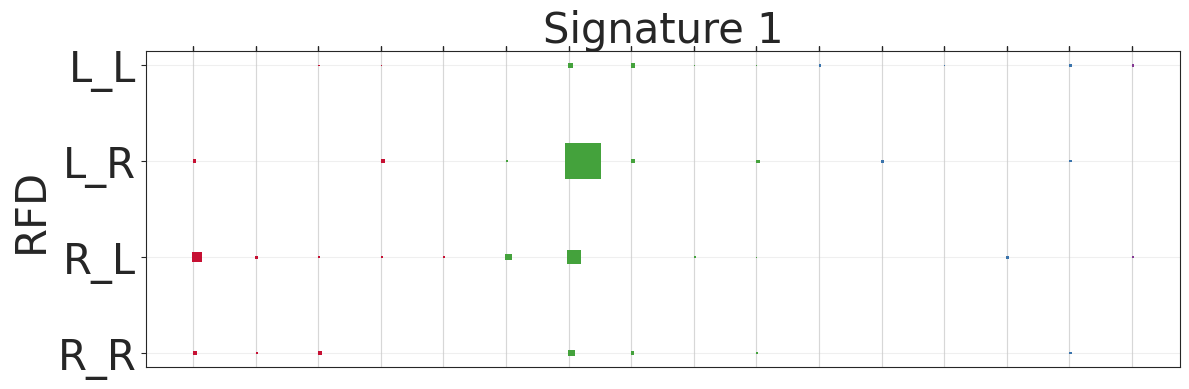

/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel//Signature 2 sil score: 0.67.jpg


writing PDF
/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 2 sil score: 0.67.pdf


writing PDF: /home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 2_only_dups.pdf


/tmp/ipykernel_2151685/1704116018.py:62: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



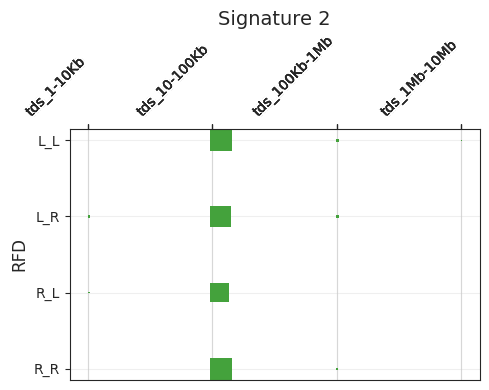

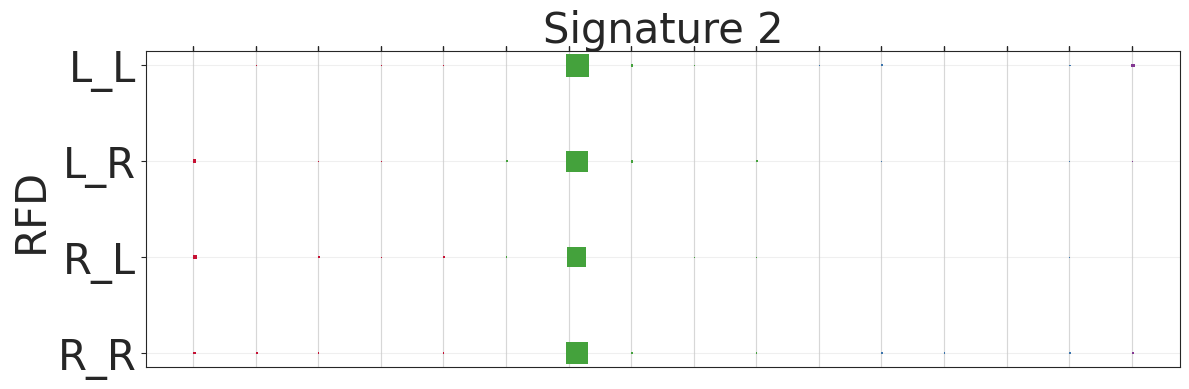

/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel//Signature 3 sil score: 0.95.jpg


writing PDF
/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 3 sil score: 0.95.pdf


writing PDF: /home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 3_only_dups.pdf


/tmp/ipykernel_2151685/1704116018.py:62: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



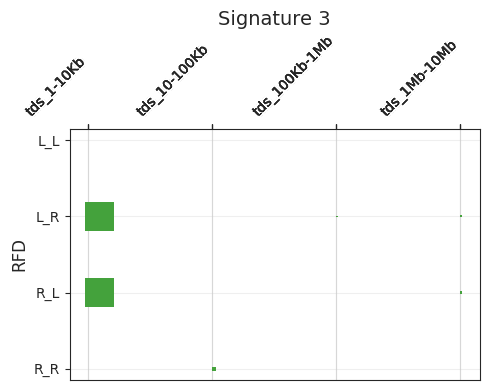

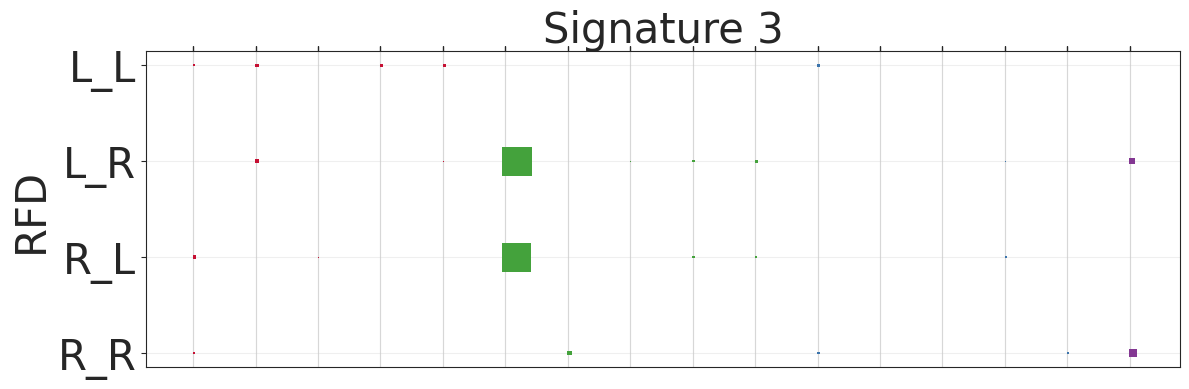

/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel//Signature 4 sil score: 0.85.jpg


writing PDF
/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 4 sil score: 0.85.pdf


writing PDF: /home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 4_only_dups.pdf


/tmp/ipykernel_2151685/1704116018.py:62: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



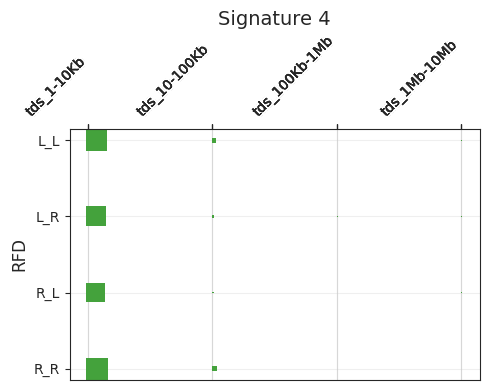

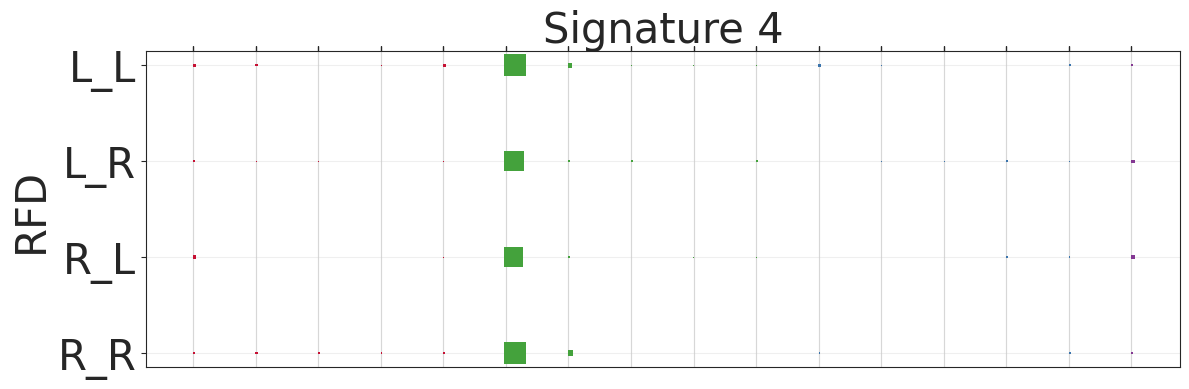

/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel//Signature 5 sil score: 0.93.jpg


writing PDF
/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 5 sil score: 0.93.pdf


writing PDF: /home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 5_only_dups.pdf


/tmp/ipykernel_2151685/1704116018.py:62: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



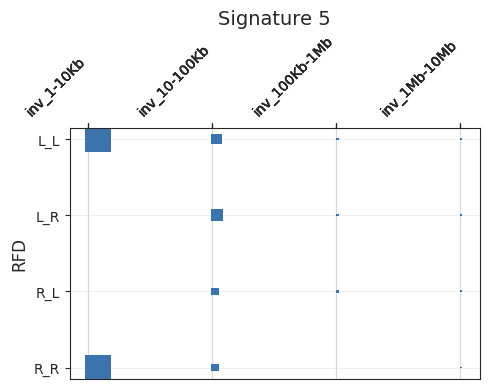

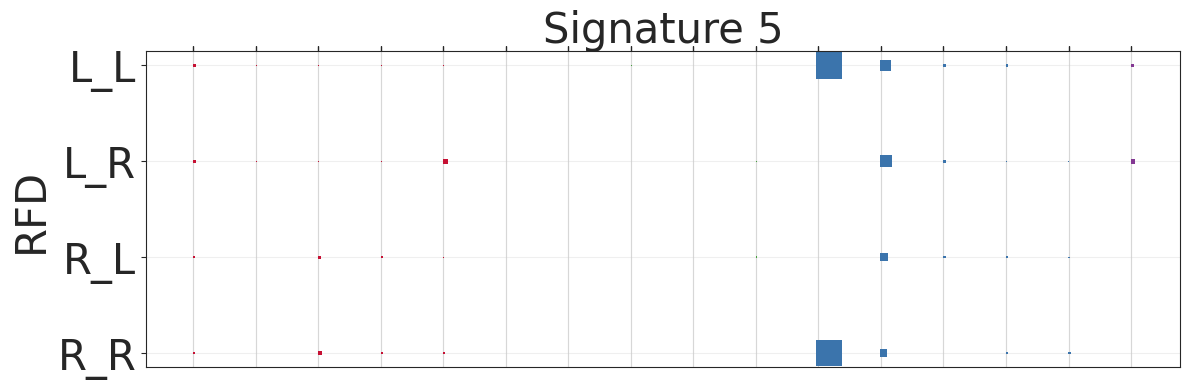

/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel//Signature 6 sil score: 0.85.jpg


writing PDF
/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 6 sil score: 0.85.pdf


writing PDF: /home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 6_only_dups.pdf


/tmp/ipykernel_2151685/1704116018.py:62: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



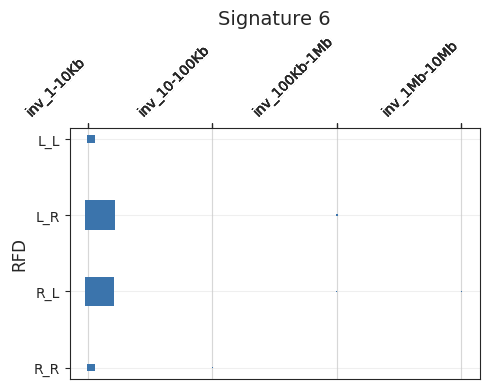

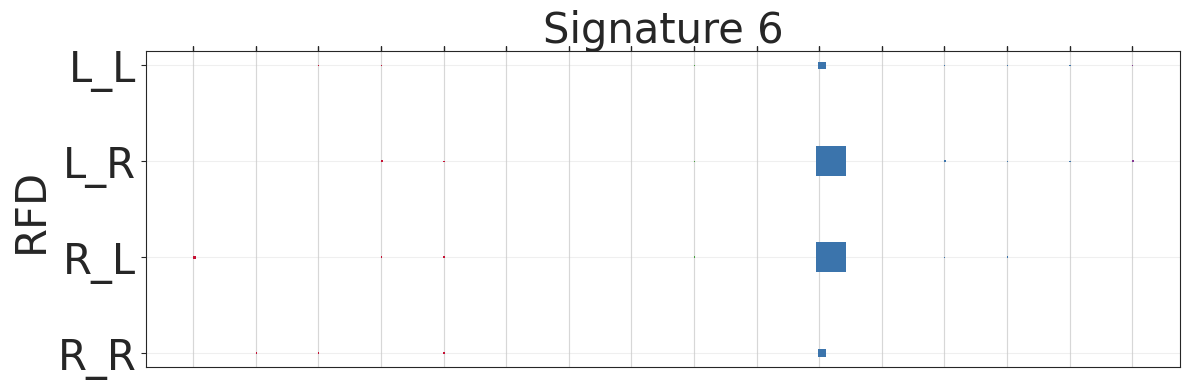

/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel//Signature 7 sil score: 0.52.jpg


writing PDF
/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 7 sil score: 0.52.pdf


writing PDF: /home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 7_only_dups.pdf


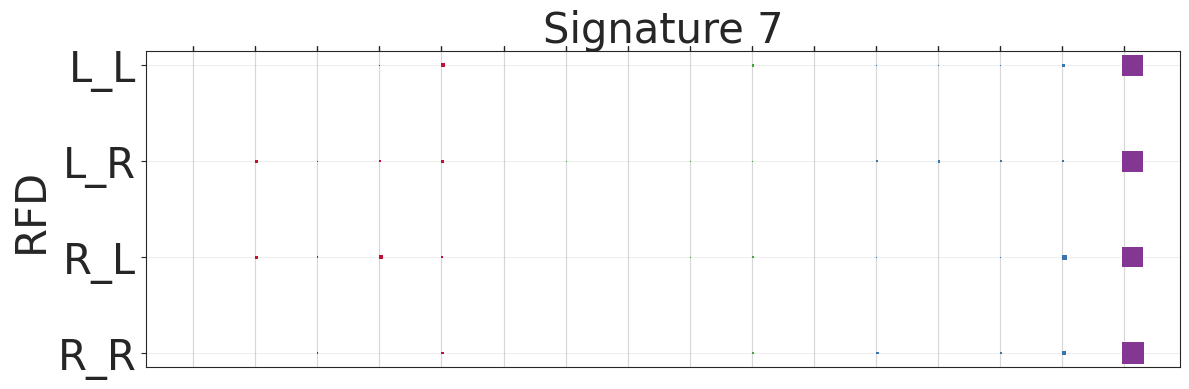

/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel//Signature 8 sil score: 0.98.jpg


writing PDF
/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 8 sil score: 0.98.pdf


writing PDF: /home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 8_only_dups.pdf


/tmp/ipykernel_2151685/1704116018.py:62: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



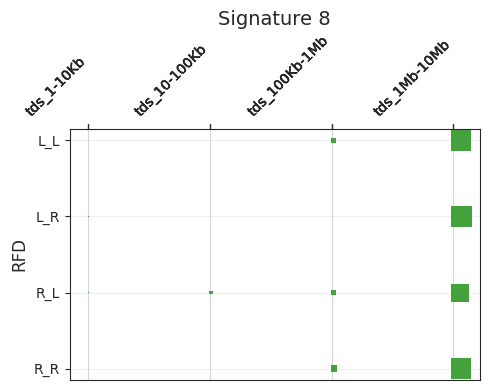

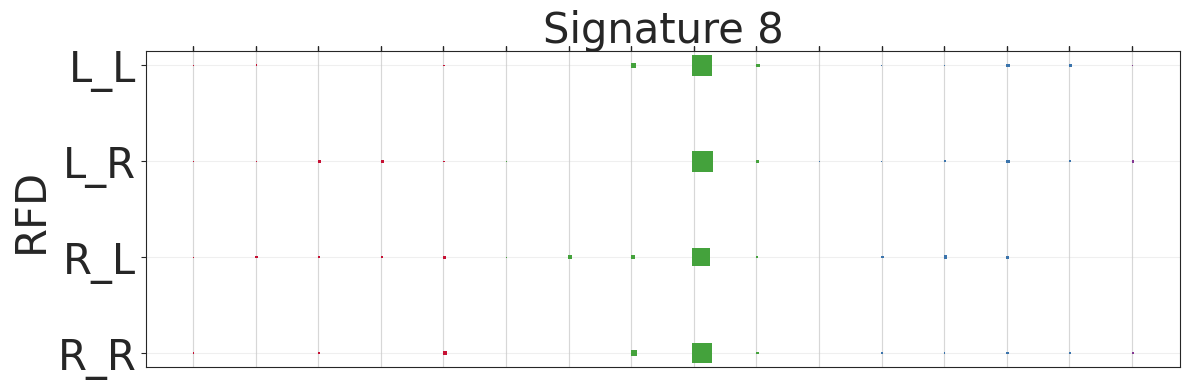

/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel//Signature 9 sil score: 0.88.jpg


writing PDF
/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 9 sil score: 0.88.pdf


writing PDF: /home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 9_only_dups.pdf


/tmp/ipykernel_2151685/1704116018.py:62: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



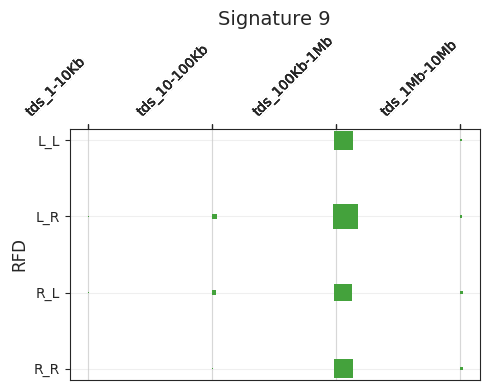

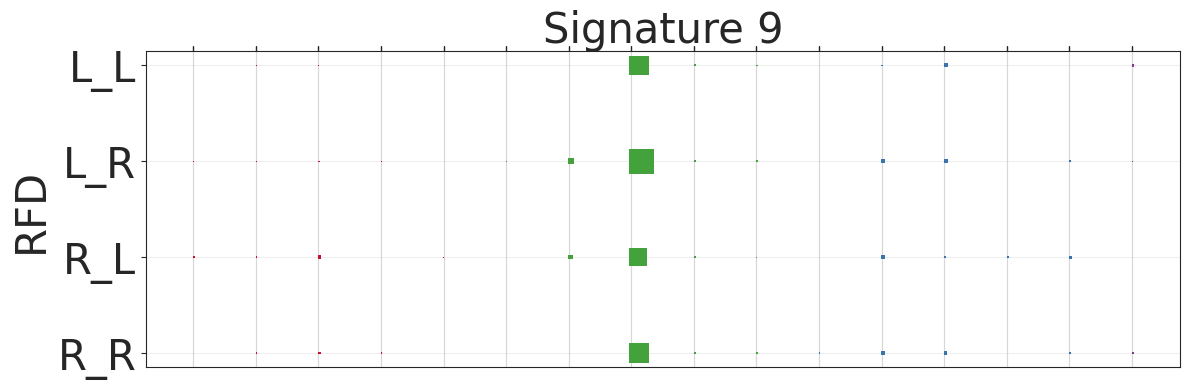

/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel//Signature 10 sil score: 0.94.jpg


writing PDF
/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 10 sil score: 0.94.pdf


writing PDF: /home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 10_only_dups.pdf


/tmp/ipykernel_2151685/1704116018.py:62: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



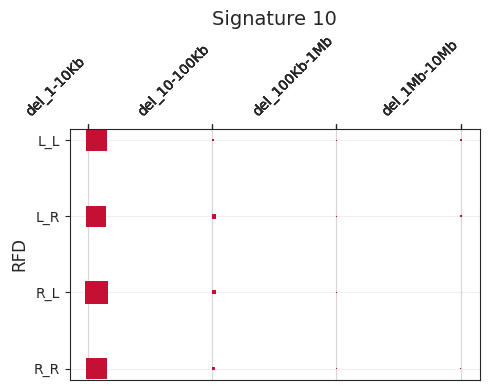

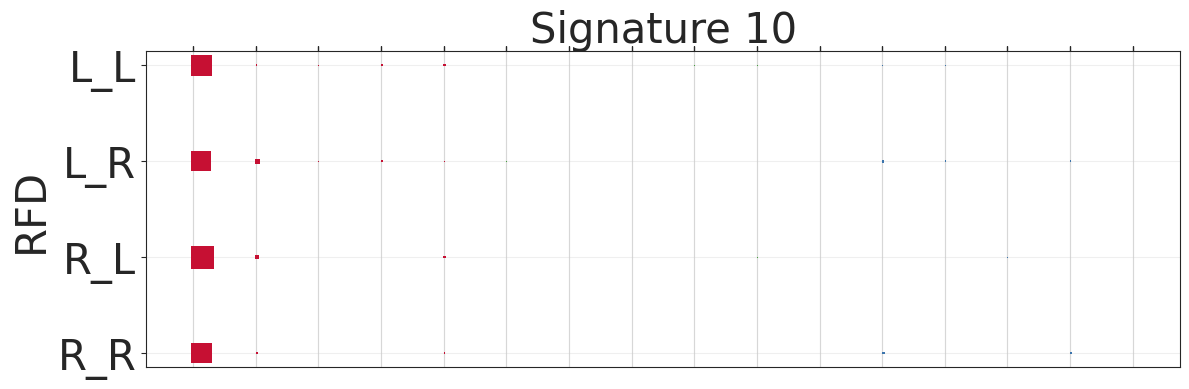

/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel//Signature 11 sil score: 0.82.jpg


writing PDF
/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 11 sil score: 0.82.pdf


writing PDF: /home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 11_only_dups.pdf


/tmp/ipykernel_2151685/1704116018.py:62: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



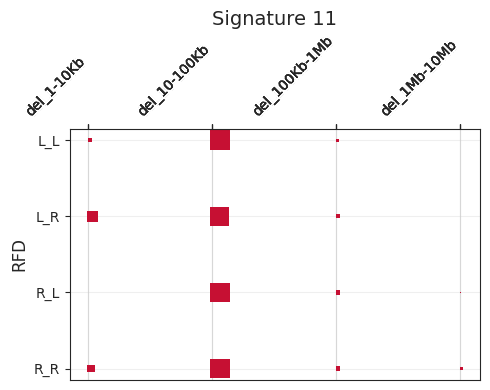

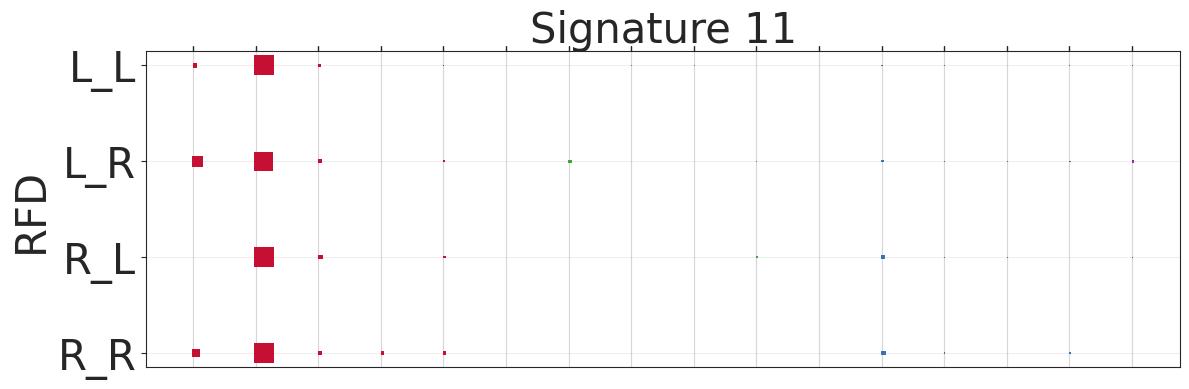

/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel//Signature 12 sil score: 0.69.jpg


writing PDF
/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 12 sil score: 0.69.pdf


writing PDF: /home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 12_only_dups.pdf


/tmp/ipykernel_2151685/1704116018.py:62: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



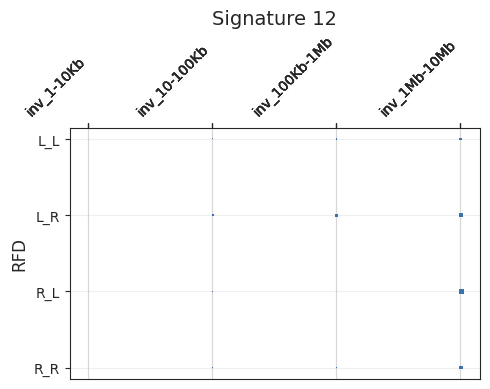

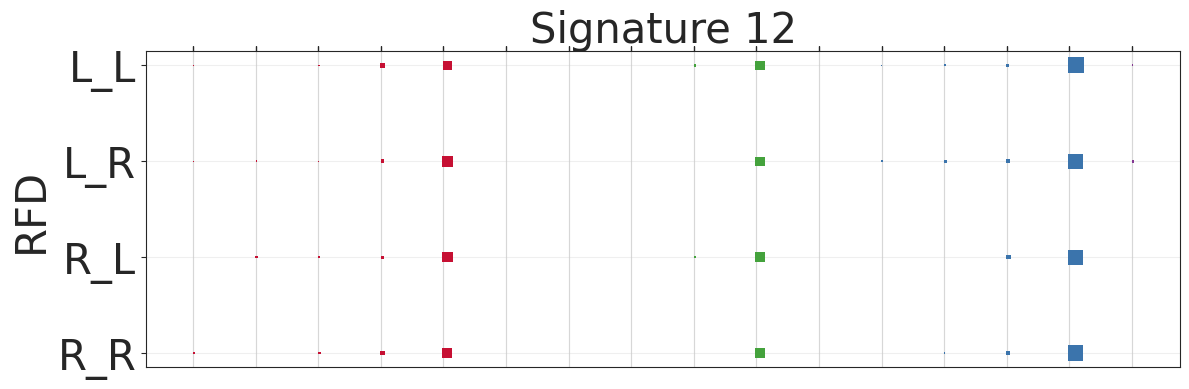

/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel//Signature 13 sil score: 0.47.jpg


writing PDF
/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 13 sil score: 0.47.pdf


writing PDF: /home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 13_only_dups.pdf


/tmp/ipykernel_2151685/1704116018.py:62: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



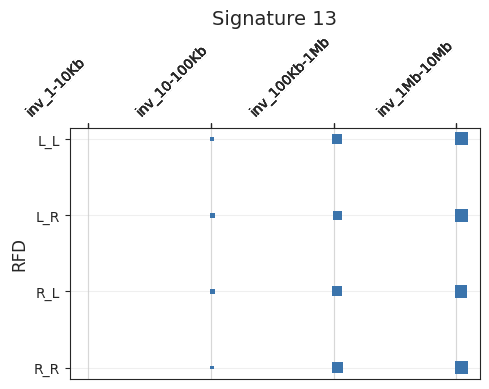

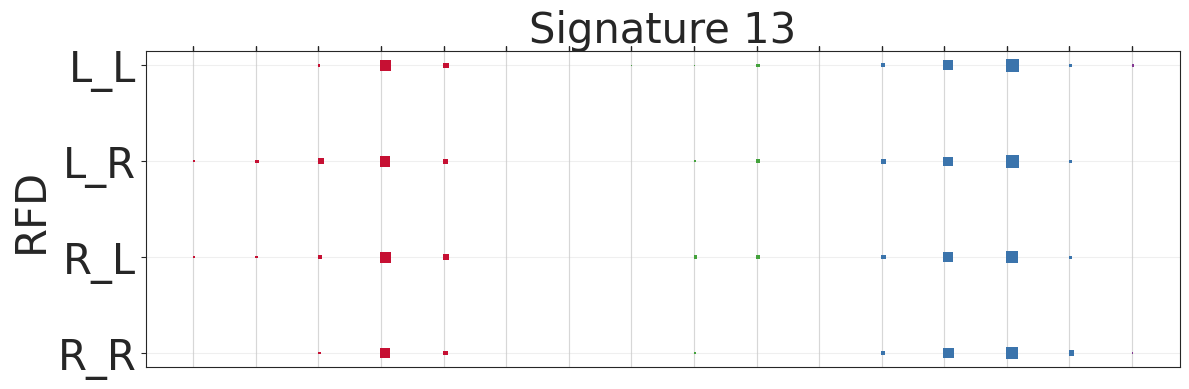

/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel//Signature 14 sil score: 0.83.jpg


writing PDF
/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 14 sil score: 0.83.pdf


writing PDF: /home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 14_only_dups.pdf


/tmp/ipykernel_2151685/1704116018.py:62: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



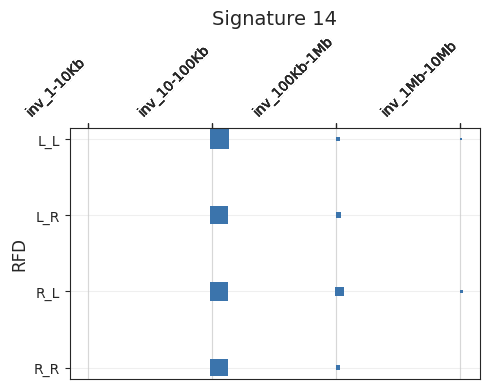

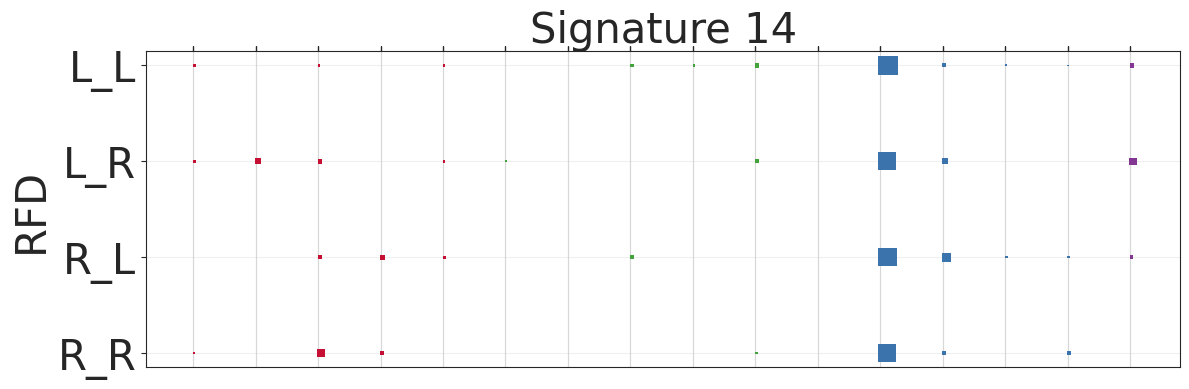

/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel//Signature 15 sil score: 0.87.jpg


writing PDF
/home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 15 sil score: 0.87.pdf


writing PDF: /home/dg204/park_dglodzik/SVsigs/RFD/non_clustered_pancan_sel_corr//Signature 15_only_dups.pdf


/tmp/ipykernel_2151685/1704116018.py:62: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



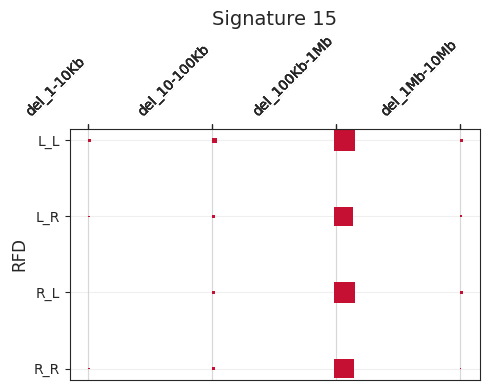

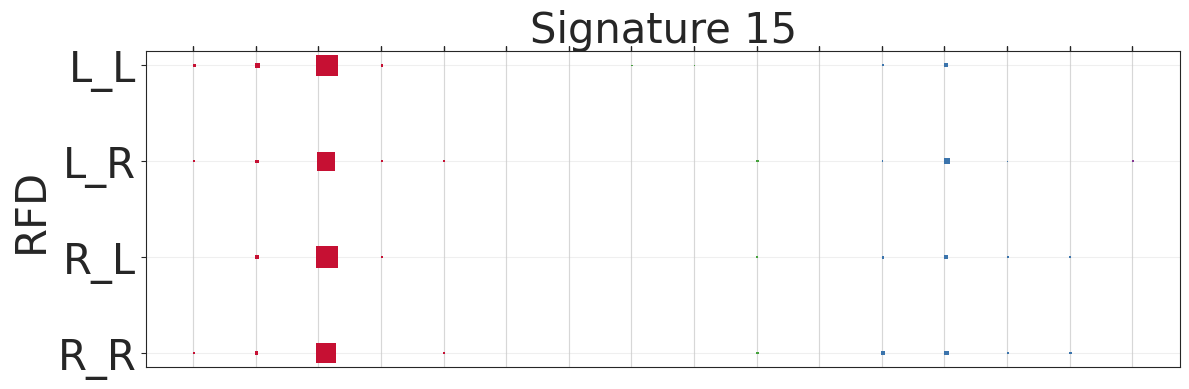

In [66]:
# ----------------- Loop through all signatures -----------------
for sig in deNovoSigs.columns:
#for sig in deNovoSigs.columns:    
    mut_spectrum = deNovoSigs[[sig]].reset_index(names='MutationType').rename(columns={sig:'Total Count'})
    plot_mut_spectrum(mut_spectrum, sorted_array, color_map, title=sig + ' sil score: ' + str(round(sil_scores_dict[sig],2)), output_dir=output_dir, show=True)

    mut_spectrum_reindexed = mut_spectrum.copy()
    mut_spectrum_reindexed.index = mut_spectrum_reindexed['MutationType']
    
    colnames_sel = [c for c in SORTED_CAT_ARRAY if 'non-clustered' in c]
    corr_df = pd.read_csv('/home/dg204/park_dglodzik/svig/non_clustered_shuffle_simple/rfd_counts_non_clustered_shuffle_simple.csv', index_col=0)
    corr_df['cat32'] = ['_'.join(c.rsplit('_', 2)[:-2]) for c in corr_df.index]
    corr_df['count_per_cat32'] = corr_df.groupby('cat32')['count'].transform('sum')
    corr_df['corr'] = corr_df['count'] / corr_df['count_per_cat32']
    corr_df.sort_index(inplace=True)
    
    X_nonclust = mut_spectrum_reindexed.loc[colnames_sel,'Total Count']
    X_nonclust_corr = X_nonclust.div(corr_df.loc[X_nonclust.index, 'corr'].values, axis=0)
    X_nonclust_corr = X_nonclust_corr/X_nonclust_corr.sum()
    
    mut_spectrum_reindexed.loc[:,'Total Count'] = X_nonclust_corr
    #mut_spectrum_reindexed.reset_index()
    mut_spectrum_reindexed = mut_spectrum_reindexed.drop(columns=["MutationType"])
    mut_spectrum_reindexed = mut_spectrum_reindexed.reset_index()
    sorted_array_dups = [c for c in sorted_array if 'non-clustered_tds' in c]
    plot_mut_spectrum(mut_spectrum_reindexed, sorted_array, color_map, title=sig + ' sil score: ' + str(round(sil_scores_dict[sig],2)), output_dir=output_dir_corr, show=True, showPdf=True)
    plot_mut_spectrum2(mut_spectrum_reindexed, sorted_array, color_map, title=sig + '_only_dups', output_dir=output_dir_corr, show=True, showPdf=True, only_nonclustered_td=True)

    mut_spectrum_reindexed['rfd'] = mut_spectrum_reindexed['MutationType'].str[-3:]
    mut_spectrum_reindexed['class'] = mut_spectrum_reindexed['MutationType'].str[14:-4]
    mut_spectrum_reindexed['sv_type'] = mut_spectrum_reindexed['class']
    mut_spectrum_reindexed['prefix'] = mut_spectrum_reindexed['class'].str.split('_').str[0]
    mut_spectrum_reindexed['col'] = [colDict[prefix] for prefix in mut_spectrum_reindexed['prefix']]
    
    dup_sum = mut_spectrum_reindexed.loc[mut_spectrum_reindexed['prefix']=='tds', 'Total Count'].sum()
    del_sum = mut_spectrum_reindexed.loc[mut_spectrum_reindexed['prefix']=='del', 'Total Count'].sum()
    inv_sum = mut_spectrum_reindexed.loc[mut_spectrum_reindexed['prefix']=='inv', 'Total Count'].sum()
    order = ["L_L", "L_R", "R_L", "R_R"][::-1] # your chosen order

    mut_spectrum_reindexed["rfd"] = pd.Categorical(
        mut_spectrum_reindexed["rfd"],
        categories=order,
        ordered=True
    )

    if (dup_sum>0.5):
        mut_spectrum_reindexed_sel = mut_spectrum_reindexed.loc[(mut_spectrum_reindexed['prefix']=='tds') & (mut_spectrum_reindexed['sv_type']!='tds_>10Mb'),:]
    elif (del_sum>0.5):
        mut_spectrum_reindexed_sel = mut_spectrum_reindexed.loc[(mut_spectrum_reindexed['prefix']=='del') & (mut_spectrum_reindexed['sv_type']!='del_>10Mb'),:]
    elif (inv_sum>0.5):
        mut_spectrum_reindexed_sel = mut_spectrum_reindexed.loc[(mut_spectrum_reindexed['prefix']=='inv') & (mut_spectrum_reindexed['sv_type']!='inv_>10Mb'),:]
                         

    if ((dup_sum>0.5) or (del_sum>0.5) or (inv_sum>0.5)):    
        
        # Example bubble plot
        
        plt.figure(figsize=(5, 4))



        mut_spectrum_reindexed_sel["rfd"] = pd.Categorical(
            mut_spectrum_reindexed_sel["rfd"],
            categories=order,
            ordered=True
        )

        # Convert classes to integer positions
        x = pd.factorize(mut_spectrum_reindexed_sel['class'])[0]
        y = mut_spectrum_reindexed_sel['rfd'].cat.codes
        s = mut_spectrum_reindexed_sel['Total Count'].values * 1000
        
        ax = plt.gca()
        # Make sure layout is known before coordinate transform
        plt.scatter(x, y, s=s, alpha=0)  # invisible points to set axis scale
        plt.gcf().canvas.draw()
        
        # Convert marker size from points to data units to compute half-width
        side_pts = np.sqrt(s)  # full side length in points
        trans = ax.transData.inverted()
        half_widths_data = []
        
        for xi, w_pts in zip(x, side_pts):
            x0_disp = ax.transData.transform((xi, 0))
            x1_disp = (x0_disp[0] + w_pts / 2, x0_disp[1])  # 👉 half width!
            x1_data = trans.transform(x1_disp)
            half_widths_data.append(x1_data[0] - xi)
        
        half_widths_data = np.array(half_widths_data)
        
        # Shift x to the RIGHT by half width → left edge aligns at original x
        x_shifted = x + half_widths_data
        
        # Actual scatter plot
        plt.scatter(
            x=x_shifted,
            y=y,
            s=s,
            c=mut_spectrum_reindexed_sel['col'],
            edgecolors='none',
            marker='s'
        )
        ax.set_yticks(range(len(order)))
        ax.set_yticklabels(order)

        # Axis formatting
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')
        ax.set_xticks(x)
        ax.set_xticklabels(mut_spectrum_reindexed_sel['class'], rotation=45, ha='right')
        
        plt.ylabel('RFD', fontsize=12)
        plt.title(sig, fontsize=14)
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        output_path = f"{output_dir_corr}/{sig}_scatter_leftaligned.pdf"
        plt.savefig(output_path, format='pdf', dpi=300)
        plt.show()

        

    plt.figure(figsize=(12, 4))
    
    # Convert classes to integer positions
    x = pd.factorize(mut_spectrum_reindexed['class'])[0]
    y = mut_spectrum_reindexed['rfd'].cat.codes
    s = mut_spectrum_reindexed['Total Count'].values * 1000
    
    ax = plt.gca()
    # Make sure layout is known before coordinate transform
    plt.scatter(x, y, s=s, alpha=0)  # invisible points to set axis scale
    plt.gcf().canvas.draw()
    
    # Convert marker size from points to data units to compute half-width
    side_pts = np.sqrt(s)  # full side length in points
    trans = ax.transData.inverted()
    half_widths_data = []
    
    for xi, w_pts in zip(x, side_pts):
        x0_disp = ax.transData.transform((xi, 0))
        x1_disp = (x0_disp[0] + w_pts / 2, x0_disp[1])  # 👉 half width!
        x1_data = trans.transform(x1_disp)
        half_widths_data.append(x1_data[0] - xi)
    
    half_widths_data = np.array(half_widths_data)
    
    # Shift x to the RIGHT by half width → left edge aligns at original x
    x_shifted = x + half_widths_data
    
    # Actual scatter plot
    plt.scatter(
    x=x_shifted,
    y=y,
    s=s,
    alpha=1,
    c=mut_spectrum_reindexed['col'],
    edgecolors='none',
    marker='s'
    )
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    
    # Axis formatting
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
    # ❌ Remove x-axis labels and ticks completely
    ax.set_xticks(x)                      # one tick per class
    ax.set_xticklabels([])                # hide labels, keep ticks for grid
    
    ax.grid(True, which='both', axis='both', alpha=0.3)
    
    # ✅ Enlarge y-axis label and title 2.5×
    base_fontsize = 12
    ax.set_ylabel('RFD', fontsize=base_fontsize * 2.5)
    ax.set_title(sig, fontsize=base_fontsize * 2.5)
    
    # Also enlarge y-tick labels
    ax.tick_params(axis='y', labelsize=base_fontsize * 2.5)
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.tight_layout()
    output_path = f"{output_dir_corr}/{sig}_scatter_all_leftaligned.pdf"
    plt.savefig(output_path, format='pdf', dpi=300)
    plt.show()

In [ ]:
corr_matrix = H_sel.corr(method='pearson')

plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pearson Correlation Heatmap")
plt.show()

In [ ]:
# Color palette (20 distinct colors)
colors = plt.cm.tab20(np.linspace(0, 1, len(H_sel.columns)))

# Line styles to cycle through
line_styles = ['-', '--', '-.', ':']

plt.figure(figsize=(15, 15))
for i, col in enumerate(H_sel.columns):
    sorted_vals = H_sel[col].sort_values().values
    cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)

    # Pick color and line style
    color = colors[i % len(colors)]
    ls = line_styles[i % len(line_styles)]

    plt.plot(sorted_vals, cdf, linewidth=1.5, color=color, linestyle=ls, label=col)

plt.xlabel("Value")
plt.ylabel("CDF")
plt.title("CDF of each column")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # put legend outside
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def heatmap_style(g):
    """
    Apply consistent styling to a seaborn clustermap,
    reposition colorbar, make it smaller, and add vertical lines every 16 columns.
    """
    if hasattr(g, 'ax_heatmap'):  # clustermap
        ax = g.ax_heatmap
        cbar = g.cax

        # Shrink heatmap slightly to leave space for colorbar
        pos = ax.get_position()
        ax.set_position([pos.x0, pos.y0, pos.width*0.85, pos.height])

        # Reposition colorbar (smaller width)
        cbar.set_position([0.88, pos.y0, 0.015, pos.height])
        cbar.tick_params(width=0.5, length=4, labelsize=10)

        # Ticks styling
        ax.tick_params(axis='both', width=0.5, length=4)

        # --- Add vertical lines every 16 columns ---
        n_cols = len(ax.get_xticklabels())
        #for x in range(4, n_cols, 4):
        #    ax.axvline(x, color='black', linewidth=1)
    else:
        ax = g
        cbar = ax.collections[0].colorbar
        cbar.ax.set_position([0.88, 0.2, 0.015, 0.6])
        ax.tick_params(axis='both', width=0.5, length=4)
        cbar.ax.tick_params(width=0.5, length=4, labelsize=10)

        # vertical lines
        n_cols = len(ax.get_xticklabels())
        for x in range(4, n_cols, 4):
            ax.axvline(x, color='black', linewidth=1)

In [ ]:
H_sel_norm = H_sel.div(H_sel.sum(axis=1), axis=0)

In [ ]:
if labels_fn!=None:
    pb_labels = pd.read_csv(labels_fn, index_col=0)

In [ ]:
if labels_fn!=None:
    rowLabels = pb_labels.loc[H_sel_norm.index, 'label']
    unique_labels = rowLabels.unique()
    palette = sns.color_palette("tab10", len(unique_labels))  # or "Set2", "Paired", etc.
    lut = dict(zip(unique_labels, palette))
    row_colors = rowLabels.map(lut)
    

plt.figure(figsize=(12, 12))
if labels_fn!=None:    
    g = sns.clustermap(
        H_sel_norm,
        method="ward",
        metric="euclidean",
        cmap=sns.cubehelix_palette(as_cmap=True),
        dendrogram_ratio=(0.2, 0.01),
        figsize=(50, 25),
        col_cluster=False,
        row_colors=row_colors  # 👈 HERE: add the label color strip
    )
else:
    g = sns.clustermap(
        H_sel_norm,
        method="ward",
        metric="euclidean",
        cmap=sns.cubehelix_palette(as_cmap=True),
        dendrogram_ratio=(0.2, 0.01),
        figsize=(50, 25),
        col_cluster=True
    )    

heatmap_style(g)  # apply styling

cbar = g.cax
cbar.set_position([0.89, 0.4, 0.012, 0.2])  # width=0.012, height=0.9
cbar.tick_params(width=0.5, length=4, labelsize=10)

if labels_fn!=None:
    handles = [mpatches.Patch(color=color, label=label) for label, color in lut.items()]
    plt.legend(
        handles=handles,
        title="Categories",
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )

plt.show()

#g.fig.savefig(
#    "/home/dg204/projects/rsignatures/data/processed/paperPlots/SV_RFD_clustered_heatmap.pdf",   # output file
#    format="pdf",              # file format
#    dpi=600,                   # resolution (higher = sharper)
#    bbox_inches="tight"        # trims extra whitespace
#)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster

# --- Perform hierarchical clustering manually ---
Z = linkage(H_sel_norm, method="ward", metric="euclidean")

# Cut the dendrogram into 15 clusters
cluster_assignments = fcluster(Z, t=25, criterion='maxclust')

# Turn into a pandas Series (index must match H_sel_norm)
clusters = pd.Series(cluster_assignments, index=H_sel_norm.index, name="cluster")

# --- Create a color palette and map clusters to colors ---
palette = sns.color_palette("tab20", 25)  # tab20 has 20 colors, so enough for 15
lut = dict(zip(np.unique(clusters), palette))
row_colors = clusters.map(lut)

# --- Plot clustermap with cluster color bar ---
g = sns.clustermap(
    H_sel_norm,
    method="ward",
    metric="euclidean",
    cmap=sns.cubehelix_palette(as_cmap=True),
    dendrogram_ratio=(0.2, 0.01),
    figsize=(50, 25),
    col_cluster=True,
    row_colors=row_colors
)

# --- Add legend ---
handles = [plt.Line2D([0], [0], marker='o', color='w', label=f"Cluster {c}",
                      markerfacecolor=color, markersize=10) for c, color in lut.items()]
plt.legend(
    handles=handles,
    title="Clusters (n=15)",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

In [ ]:


# ✅ Make text editable in Illustrator
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# --- Label mapping ---
if labels_fn is not None:
    rowLabels = pb_labels.loc[H_sel_norm.index, 'label']
    unique_labels = rowLabels.unique()
    palette = sns.color_palette("tab10", len(unique_labels))
    lut = dict(zip(unique_labels, palette))
    row_colors = rowLabels.map(lut)
else:
    rowLabels = None

# --- Run UMAP ---
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)
embedding = reducer.fit_transform(H_sel_norm)

# --- Create DataFrame ---
umap_df = pd.DataFrame(embedding, index=H_sel_norm.index, columns=['UMAP1', 'UMAP2'])
if rowLabels is not None:
    umap_df['label'] = rowLabels.values

# --- Plot ---
plt.figure(figsize=(16, 12))

if rowLabels is not None:
    # Split into "other" and "non-other"
    df_other = umap_df[umap_df['label'] == "other"]
    df_non_other = umap_df[umap_df['label'] != "other"]

    # Plot all non-"other" points normally
    plt.scatter(
        df_other['UMAP1'],
        df_other['UMAP2'],
        s=80,
        facecolors='lightgray',     # empty fill
        edgecolors='none',    # black outline
        linewidth=0.8,
        label='other',
        zorder=1
    )
    
    # Plot all non-"other" points on top
    sns.scatterplot(
        data=df_non_other,
        x='UMAP1',
        y='UMAP2',
        hue='label',
        palette={k: v for k, v in lut.items() if k != "other"},
        s=80,
        edgecolor='none',
        linewidth=0,
        legend=True,
        zorder=2
    )

    plt.legend(title="Categories", bbox_to_anchor=(1.05, 1), loc='upper left')

else:
    plt.scatter(umap_df['UMAP1'], umap_df['UMAP2'], s=50, color='grey')

plt.title("UMAP projection of H_sel_norm", fontsize=16)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.tight_layout()

# ✅ Save Illustrator-editable vector PDF
output_path = f"{output_dir}/umap_projection.pdf"
plt.savefig(output_path, format='pdf')
print(f"Saved Illustrator-editable PDF: {output_path}")

plt.show()

In [ ]:
if labels_fn!=None:
    rowLabels = pb_labels.loc[H_sel_norm.index, 'label']
    H_sel_labeled = H_sel.copy()
    H_sel_labeled['label'] = rowLabels
    H_long = H_sel_labeled.melt(id_vars='label', var_name='column', value_name='value')
    
    plt.figure(figsize=(20, 12))
    
    sns.boxplot(
        data=H_long,
        x="column",         # Each column of H_sel
        y="value",          # Its numeric values
        hue="label",        # Conditioned on rowLabels
        palette="Set2"
    )
    
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Columns")
    plt.ylabel("Value")
    plt.title("Boxplots of column values conditioned on row label")
    plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    output_path = f"{output_dir}/signature_boxplots_all_vertical.pdf"
    plt.savefig(output_path, format="pdf")
    print(f"Saved editable PDF: {output_path}")
    plt.show()

In [ ]:
if labels_fn!=None:
    rowLabels = pb_labels.loc[H_sel_norm.index, 'label']
    H_sel_labeled = H_sel.copy()
    H_sel_labeled['label'] = rowLabels
    H_long = H_sel_labeled.melt(id_vars='label', var_name='column', value_name='value')
    
    plt.figure(figsize=(20, 12))
    
    sns.boxplot(
        data=H_long,
        x="column",         # Each column of H_sel
        y="value",          # Its numeric values
        hue="label",        # Conditioned on rowLabels
        palette="Set2"
    )
    
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Columns")
    plt.ylabel("Value")
    plt.title("Boxplots of column values conditioned on row label")
    plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.ylim([0,50])
    plt.show()

In [ ]:
H_long.head()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# ✅ Make text editable in Illustrator
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


if labels_fn is not None:
    rowLabels = pb_labels.loc[H_sel_norm.index, 'label']
    H_sel_labeled = H_sel.copy()
    H_sel_labeled['label'] = rowLabels
    
    H_long = H_sel_labeled.melt(id_vars='label', var_name='column', value_name='value')
    
    H_long_sel = H_long.loc[
        H_long['column'].isin([
            'Signature 1', 'Signature 2', 'Signature 3',
            'Signature 4', 'Signature 8', 'Signature 9'
        ]),
        :
    ]
    
    signature_order = [
        'Signature 4', 'Signature 3', 'Signature 2',
        'Signature 1', 'Signature 9', 'Signature 8'
    ]

    # Create subplots — one row per signature
    n_signatures = len(signature_order)
    fig, axes = plt.subplots(nrows=n_signatures, ncols=1, figsize=(8, 2.5 * n_signatures), sharey=False)

    if n_signatures == 1:
        axes = [axes]

    for ax, sig in zip(axes, signature_order):
        data_sig = H_long_sel[H_long_sel['column'] == sig]

        sns.boxplot(
            data=data_sig,
            x="value",
            y="label",
            hue="label",
            palette="Set2",
            legend=False,
            ax=ax
        )

        ax.set_title(sig, fontsize=14)
        ax.set_xlabel("Value")
        ax.set_ylabel("Label")

        # ✅ Custom x-axis range for ~95% of data
        lower = np.percentile(data_sig['value'], 2.5)
        upper = np.percentile(data_sig['value'], 97.5)
        margin = (upper - lower) * 0.05  # small margin to avoid clipping

        if sig=='Signature 8':
            ax.set_xlim(lower - margin, 300)
        elif sig=='Signature 9':
            ax.set_xlim(lower - margin, 300)
        else:
            ax.set_xlim(lower - margin, upper + margin)

        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.suptitle("Boxplots of Signatures (zoomed to 95% of values)", y=1.02, fontsize=16)
    output_path = f"{output_dir}/signature_boxplots.pdf"
    plt.savefig(output_path, format="pdf")
    print(f"Saved editable PDF: {output_path}")
    plt.show()

In [ ]:
sig

In [ ]:
if labels_fn!=None:
    brca_spectrum = pd.DataFrame(X.loc[:,rowLabels=='BRCA1'].sum(axis=1))
    brca_spectrum = brca_spectrum.reset_index().rename(columns={'Mutation type': 'MutationType'})
    brca_spectrum = brca_spectrum.rename(columns={brca_spectrum.columns[1]: "Total Count"})
    plot_mut_spectrum(brca_spectrum, sorted_array, color_map, title='BRCA1 spectrum', output_dir=output_dir, show=True)
    
    brca_spectrum = pd.DataFrame(X.loc[:,rowLabels=='BRCA2'].sum(axis=1))
    brca_spectrum = brca_spectrum.reset_index().rename(columns={'Mutation type': 'MutationType'})
    brca_spectrum = brca_spectrum.rename(columns={brca_spectrum.columns[1]: "Total Count"})
    plot_mut_spectrum(brca_spectrum, sorted_array, color_map, title='BRCA2 spectrum', output_dir=output_dir, show=True)
    
    brca_spectrum = pd.DataFrame(X.loc[:,rowLabels=='CCNE1'].sum(axis=1))
    brca_spectrum = brca_spectrum.reset_index().rename(columns={'Mutation type': 'MutationType'})
    brca_spectrum = brca_spectrum.rename(columns={brca_spectrum.columns[1]: "Total Count"})
    plot_mut_spectrum(brca_spectrum, sorted_array, color_map, title='CCNE1 spectrum', output_dir=output_dir, show=True)

In [ ]:

plt.figure(figsize=(30, 10))

start_idx = 0
tick_positions = []
tick_labels = []

for col in H_sel.columns:
    sorted_values = H_sel[col].sort_values().reset_index(drop=True)
    x_positions = range(start_idx, start_idx + len(sorted_values))
    
    # Plot points with smaller size
    plt.scatter(x_positions, sorted_values, label=col, alpha=0.7, s=10)
    
    # Add median line
    median_val = np.median(sorted_values)
    plt.hlines(median_val, start_idx, start_idx + len(sorted_values) - 1, 
               colors='red', linestyles='--', linewidth=2, alpha=0.8)
    
    # Save position for x-ticks (middle of section)
    tick_positions.append(start_idx + len(sorted_values) // 2)
    tick_labels.append(col)
    
    # Update start for next section
    start_idx += len(sorted_values) + 2  # +2 adds a small gap between sections

plt.xticks(tick_positions, tick_labels, rotation=45, ha='right')
plt.xlabel("Column")
plt.ylabel("Values")
plt.title("Sorted Values per Column (Single Scatter Plot with Median Lines)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
sorted_values = H_sel['Signature 3'].sort_values()

In [ ]:
corr_matrix = H_sel.corr(method='pearson')

plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pearson Correlation Heatmap")
plt.show()

In [ ]:
curated_cdk12=['0009b464-b376-4fbc-8a56-da538269a02f',
                  '84ca6ab0-9edc-4636-9d27-55cdba334d7d',
                  'b243adb4-b3e7-4e0e-bc0d-625aa8dbb1be',
                   '89dad92e-5b3f-479a-a6da-a94ee7df7f8a',
                   'bc0dee07-de20-44d6-be65-05af7e63ac96',
                   '36d1a85e-a09b-4537-86e0-eaf1eb03aed8',
                   '0bfd1043-816e-e3e4-e050-11ac0c4860c5']
ccne_samples_df=pd.read_csv('~/projects/rsignatures/data/processed/CCNE1.amp.sample.csv')
andrea_s8 = pd.read_csv('/home/dg204/projects/rsignatures/data/external/Andrea/Andrea.S8.csv',  index_col=0)
#andrea_s8_sel = andrea_s8.loc[[c for c in andrea_s8.index if c in X.columns],: ]

hrd_brca_loh = pd.read_csv('~/projects/rsignatures/data/processed/BRCA_and_LOH_PCAWG.tsv', sep='\t', index_col=0)
#hrd_brca_loh = hrd_brca_loh.loc[[c for c in  andrea_s8.index if c in X.columns],: ]




pcawg_labels = pd.DataFrame('other', index=andrea_s8.index, columns=['label'])
pcawg_labels.loc[[c for c in ccne_samples_df['aliquot_id'] if c in pcawg_labels.index], 'label'] = 'CCNE1'
pcawg_labels.loc[[c for c in hrd_brca_loh.index if c in pcawg_labels.index] ,'label'] =  hrd_brca_loh['chord.genotype']
pcawg_labels.loc[[c for c in curated_cdk12 if c in pcawg_labels.index]  , 'label'] = 'CDK12' 

pcawg_labels.loc[andrea_s8.index,'HRDetect'] = andrea_s8['HRDetect single score']
pcawg_labels['HRD_label'] = 'HRP' 
pcawg_labels['HRD_label'] = ['HRD' if c>0.7 else 'HRP' for c in pcawg_labels['HRDetect'] ]

pcawg_labels.to_csv('/home/dg204/projects/rsignatures/data/processed/pcawg_labels_v2.csv')
